# JD+ WS Python client demo

In [7]:
from generator import generate_ts_data
from mapper import TsDataMapper
from models import Frequency, Observation, AggregationType, TsData, TsPeriod
from src.client import CommunicationManager
from datetime import date
import matplotlib.pyplot as plt

In [8]:
communicationManager = CommunicationManager()

## Descriptive Statistics

N              160
N Missing      0
Max            1302.3699612479809
Min            13.35130195804137
Average        485.6966288502692
StDev          311.92932389110814
Q25            228.11353328764613
Q50            426.8122884379645
Q75            736.0516707624938


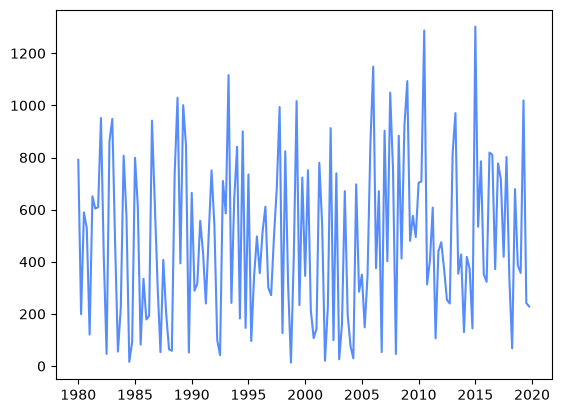

In [9]:
data_descriptive = generate_ts_data(1980, 0, Frequency.QUARTERLY, 160, True)
plt.plot(*zip(*sorted(data_descriptive.get_date_values().items())), label="Original")

descriptive_statistics = communicationManager.get_descriptive_statistics(data_descriptive)
print(descriptive_statistics)

## Temporal Disaggregation

In [10]:
# Create series that will be disaggregated
y = TsData(start=TsPeriod(year=1977, position=0, frequency=Frequency.YEARLY),
           values=(500.0,510.0,525.0,520.0))

# Call engine
disaggregated = communicationManager.process_temporal_disaggregation(y, False, False, "Rw", 12, False, 0, False, 0, False, "SqrtDiffuse", False, 0, 6)

Display disaggregation results

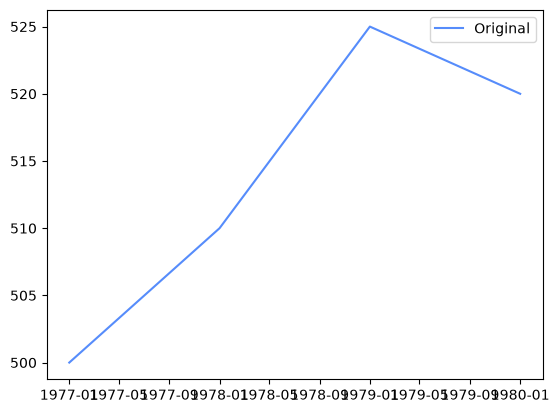

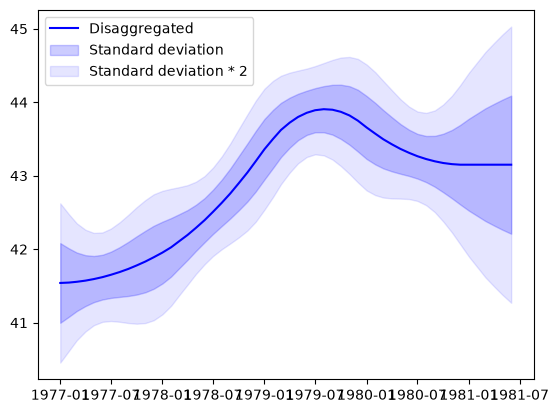

In [11]:
df = disaggregated.as_dataframe()

plt.plot(*zip(*sorted(y.get_date_values().items())), label="Original")
plt.legend()
plt.show()

plt.plot(df.index,df["disaggregated"], color="blue", label="Disaggregated")
plt.fill_between(df.index,df["disaggregated"] - df["stDevDisaggregated"],df["disaggregated"] + df["stDevDisaggregated"], color="blue", alpha=0.2, label="Standard deviation")
plt.fill_between(df.index,df["disaggregated"] - 2 * df["stDevDisaggregated"],df["disaggregated"] + 2 * df["stDevDisaggregated"], color="blue", alpha=0.1, label="Standard deviation * 2")
plt.legend()
plt.show()

In [12]:
print(disaggregated.statistics)

N Obs                    4
N Diffuse                1
N Params                 0
Degrees of freedom       3
Log likelihood           -13.775642324990464
Adjusted log likelihood  -13.775642324990464
AIC                      27.55128464998093
AICC                     27.55128464998093
BIC                      27.55128464998093
SSQ                      0.2948465293959252
LDet                     21.027577909230022
DCorrection              4.969813299576001


In [13]:
print(disaggregated.likelihood)

N Obs                    0
ll                       -13.775642324990464
ssqerr                   0.2948465293959252
ldet                     21.027577909230022
lddet                    0.0
nd                       1
nxd                      0
bvar                     Matrix(n_rows=0, n_cols=0, values=())
legacy                   False
Scaling factor           True
res                      ()
b                        ()

